In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
train_dir = "/content/drive/MyDrive/Domestic Animal/Train"
test_dir = "/content/drive/MyDrive/Domestic Animal/Test"

In [18]:
import os
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['Cat', 'Chicken', 'Cow', 'Dog', 'Goat', 'Horse']


In [19]:
corrupted_images = []  # List to store corrupted image paths

# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):  # Ensure it's a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")



No corrupted images found.


In [20]:
from collections import defaultdict

def count_images_per_class(base_dir):
    counts = defaultdict(int)
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[class_name] = len(images)
    return counts

# Count for both train and test
train_counts = count_images_per_class(train_dir)
test_counts = count_images_per_class(test_dir)

# Get full set of class names (union of both folders)
all_classes = sorted(set(train_counts.keys()) | set(test_counts.keys()))

# Print combined report
print("\nClass-wise Image Distribution")
print("=" * 65)
print(f"{'Class Name':<20}{'Train Count':>15}{'Test Count':>15}{'Total':>10}")
print("=" * 65)
for cls in all_classes:
    train_c = train_counts.get(cls, 0)
    test_c = test_counts.get(cls, 0)
    total = train_c + test_c
    print(f"{cls:<20}{train_c:>15}{test_c:>15}{total:>10}")
print("=" * 65)
print(f"{'Total Images':<20}{sum(train_counts.values()):>15}{sum(test_counts.values()):>15}{sum(train_counts.values()) + sum(test_counts.values()):>10}")



Class-wise Image Distribution
Class Name              Train Count     Test Count     Total
Cat                             540            120       660
Chicken                         540            120       660
Cow                             540            120       660
Dog                             540            120       660
Goat                            540            120       660
Horse                           540            120       660
Total Images                   3240            720      3960


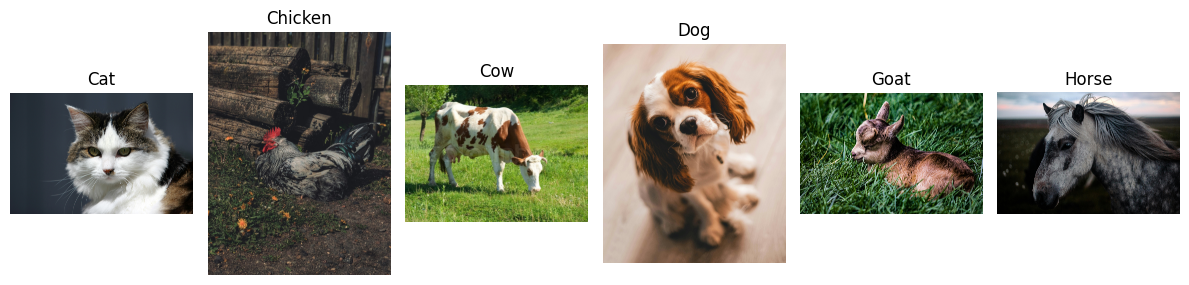

In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
fig, axes = plt.subplots(1,num_classes, figsize=(12,6))

if num_classes == 1:
    axes = [axes]

for ax, img_path, label in zip(axes, selected_images, selected_labels):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
img_height = 128
img_width = 128
batch_size = 32
seed = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

Found 3240 files belonging to 6 classes.
Using 2592 files for training.
Found 3240 files belonging to 6 classes.
Using 648 files for validation.
Found 720 files belonging to 6 classes.


In [ ]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(data_augmentation(x)), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

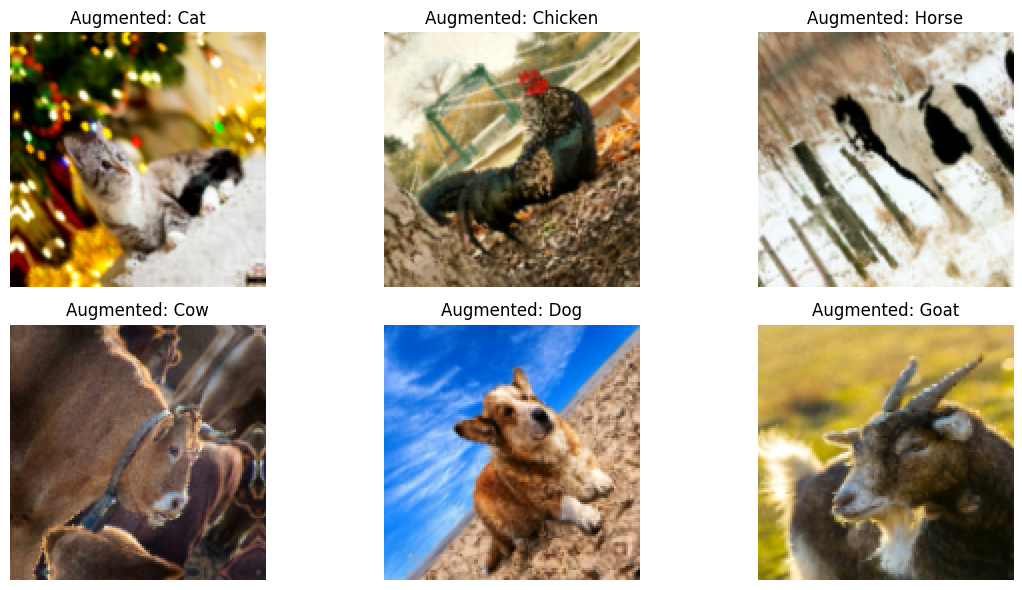

In [ ]:
num_classes = len(class_names)

sampled_augmented = {}

for image_batch, label_batch in train_ds.unbatch():
    class_index = tf.argmax(label_batch).numpy()
    class_name = class_names[class_index]

    if class_name not in sampled_augmented:
        sampled_augmented[class_name] = image_batch.numpy()

    if len(sampled_augmented) == num_classes:
        break

plt.figure(figsize=(12, 6))
for idx, (class_name, image) in enumerate(sampled_augmented.items()):
    plt.subplot(2, (num_classes + 1)//2, idx + 1)
    plt.imshow(image)
    plt.title(f"Augmented: {class_name}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
model = keras.Sequential([

    layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(6, activation="softmax")
])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,199,558 (8.39 MB)

 Trainable params: 2,199,558 (8.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model_baseline.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2024 - loss: 1.7750

81/81 ━━━━━━━━━━━━━━━━━━━━ 730s 9s/step - accuracy: 0.2029 - loss: 1.7744 - val_accuracy: 0.3256 - val_loss: 1.6866
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3155 - loss: 1.6410

81/81 ━━━━━━━━━━━━━━━━━━━━ 540s 7s/step - accuracy: 0.3158 - loss: 1.6405 - val_accuracy: 0.3580 - val_loss: 1.5854
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3781 - loss: 1.5172

81/81 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.3782 - loss: 1.5169 - val_accuracy: 0.4059 - val_loss: 1.5013
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4031 - loss: 1.4355

81/81 ━━━━━━━━━━━━━━━━━━━━ 574s 7s/step - accuracy: 0.4032 - loss: 1.4354 - val_accuracy: 0.4213 - val_loss: 1.3992
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 573s 7s/step - accuracy: 0.4456 - loss: 1.3563 - val_accuracy: 0.4321 - val_loss: 1.4051
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 623s 7s/step - accuracy: 0.4506 - loss: 1.3362 - val_accuracy: 0.4429 - val_loss: 1.4646
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 574s 7s/step - accuracy: 0.4741 - loss: 1.2966 - val_accuracy: 0.4645 - val_loss: 1.4288
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 539s 7s/step - accuracy: 0.5013 - loss: 1.2528 - val_accuracy: 0.4444 - val_loss: 1.4478


Train Time 1hr 20 min

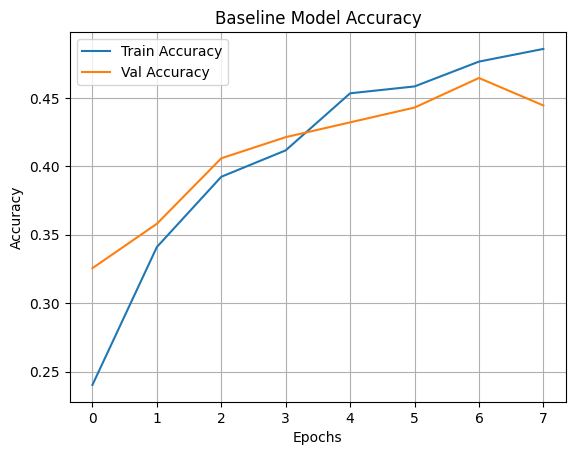

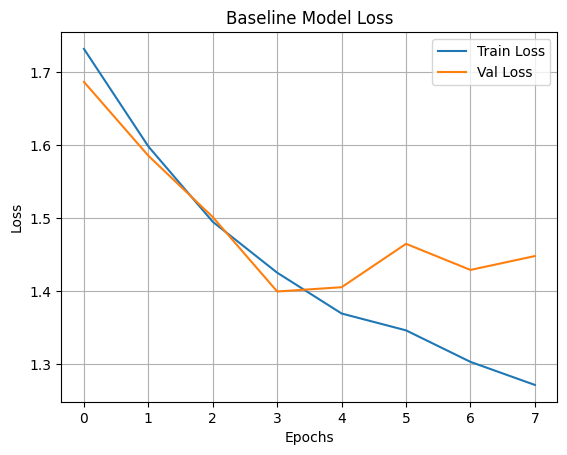

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Baseline Model Loss')
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
              precision    recall  f1-score   support

         Cat       0.51      0.28      0.36       120
    

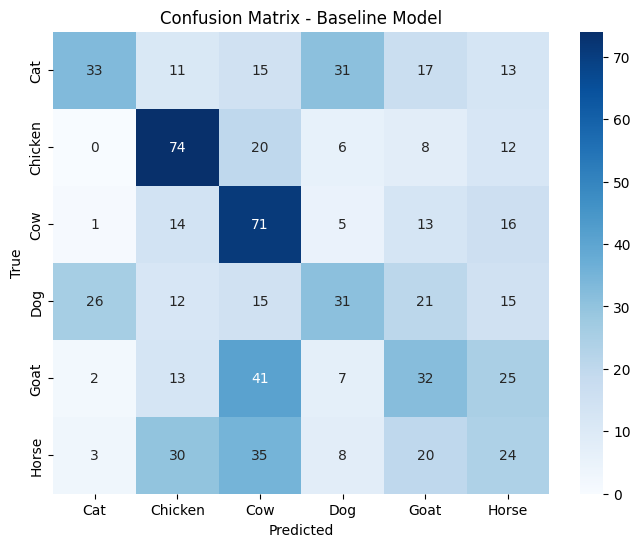

In [ ]:

y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline Model')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


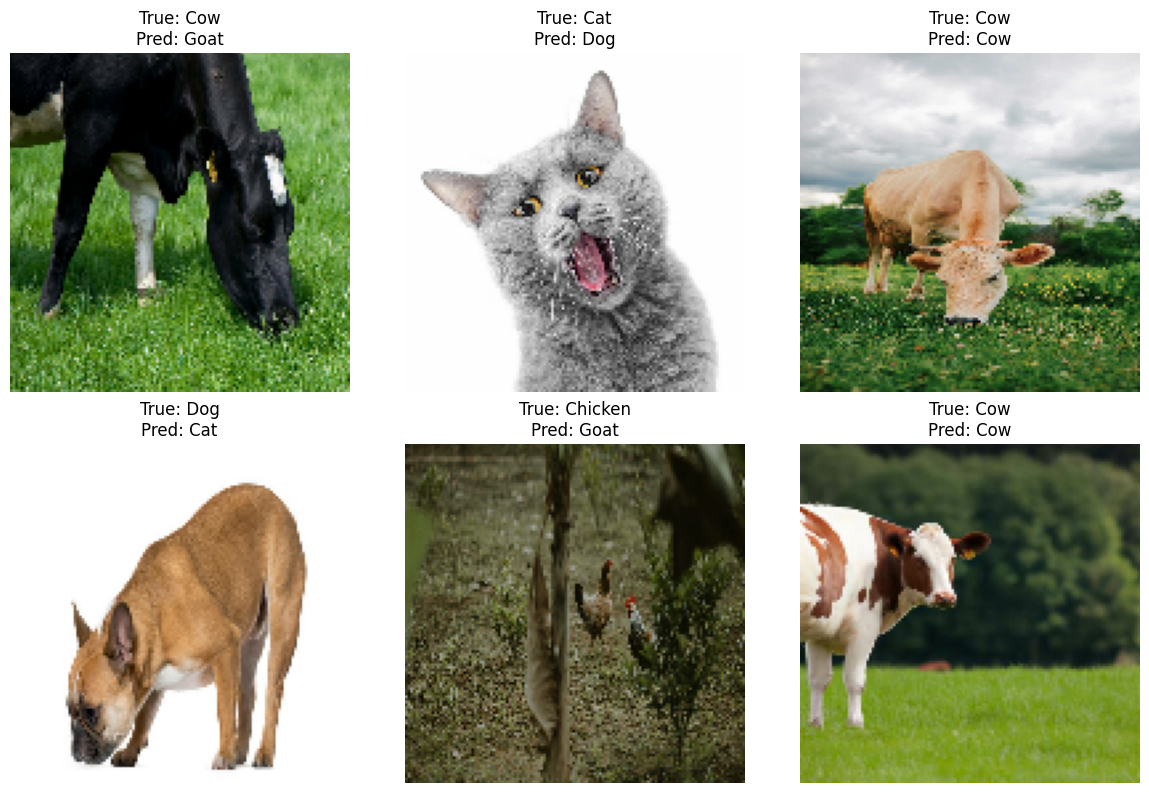

In [ ]:
for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    plt.figure(figsize=(12, 8))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow((images[i].numpy() * 255).astype("uint8"))
        plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
def build_deeper_model(input_shape, num_classes):
    model = keras.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.15))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.15))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.15))

    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.15))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

input_shape = (img_height, img_width, 3)
num_classes = len(class_names)
deeper_model = build_deeper_model(input_shape, num_classes)
deeper_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
deeper_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,710,438 (33.23 MB)

 Trainable params: 8,709,990 (33.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model_deeper.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)
]

history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.1773 - loss: 7.6738 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1147s 14s/step - accuracy: 0.1774 - loss: 7.6280 - val_accuracy: 0.1728 - val_loss: 1.7880
Epoch 2/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1157s 14s/step - accuracy: 0.2419 - loss: 1.7628 - val_accuracy: 0.1651 - val_loss: 1.7923
Epoch 3/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.2360 - loss: 1.7779 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1129s 14s/step - accuracy: 0.2362 - loss: 1.7778 - val_accuracy: 0.1698 - val_loss: 1.7755
Epoch 4/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2309 - loss: 1.7475 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1194s 14s/step - accuracy: 0.2313 - loss: 1.7471 - val_accuracy: 0.2608 - val_loss: 1.7284
Epoch 5/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.2802 - loss: 1.6923 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1140s 14s/step - accuracy: 0.2803 - loss: 1.6923 - val_accuracy: 0.3225 - val_loss: 1.6757
Epoch 6/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3026 - loss: 1.6542 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1164s 14s/step - accuracy: 0.3027 - loss: 1.6541 - val_accuracy: 0.3133 - val_loss: 1.6669
Epoch 7/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1158s 14s/step - accuracy: 0.3449 - loss: 1.5858 - val_accuracy: 0.2886 - val_loss: 1.6823
Epoch 8/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3457 - loss: 1.5796 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1137s 14s/step - accuracy: 0.3457 - loss: 1.5795 - val_accuracy: 0.3025 - val_loss: 1.6603
Epoch 9/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1133s 14s/step - accuracy: 0.3624 - loss: 1.5445 - val_accuracy: 0.3009 - val_loss: 1.6615
Epoch 10/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1177s 14s/step - accuracy: 0.3847 - loss: 1.5122 - val_accuracy: 0.2469 - val_loss: 1.7349
Epoch 11/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3724 - loss: 1.5112 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1136s 14s/step - accuracy: 0.3725 - loss: 1.5111 - val_accuracy: 0.4028 - val_loss: 1.5175
Epoch 12/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1131s 14s/step - accuracy: 0.4018 - loss: 1.4580 - val_accuracy: 0.3765 - val_loss: 1.5195
Epoch 13/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1103s 14s/step - accuracy: 0.4133 - loss: 1.4172 - val_accuracy: 0.2377 - val_loss: 1.7876
Epoch 14/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1127s 14s/step - accuracy: 0.4074 - loss: 1.4385 - val_accuracy: 0.3981 - val_loss: 1.5459
Epoch 15/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4135 - loss: 1.4410 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1151s 14s/step - accuracy: 0.4134 - loss: 1.4412 - val_accuracy: 0.3981 - val_loss: 1.5107
Epoch 16/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4206 - loss: 1.3881 

81/81 ━━━━━━━━━━━━━━━━━━━━ 1130s 14s/step - accuracy: 0.4206 - loss: 1.3884 - val_accuracy: 0.4383 - val_loss: 1.3672
Epoch 17/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1119s 13s/step - accuracy: 0.4133 - loss: 1.4031 - val_accuracy: 0.4059 - val_loss: 1.5138
Epoch 18/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1145s 14s/step - accuracy: 0.4387 - loss: 1.3522 - val_accuracy: 0.4198 - val_loss: 1.4178
Epoch 19/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1150s 14s/step - accuracy: 0.4319 - loss: 1.3574 - val_accuracy: 0.2855 - val_loss: 1.6931
Epoch 20/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1107s 14s/step - accuracy: 0.4498 - loss: 1.3894 - val_accuracy: 0.3596 - val_loss: 1.5400
Epoch 21/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1121s 14s/step - accuracy: 0.4701 - loss: 1.3147 - val_accuracy: 0.3472 - val_loss: 1.6892
Epoch 22/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 1200s 14s/step - accuracy: 0.4802 - loss: 1.2658 - val_accuracy: 0.3657 - val_loss: 1.4458


Time taken 5 hours 35 mins

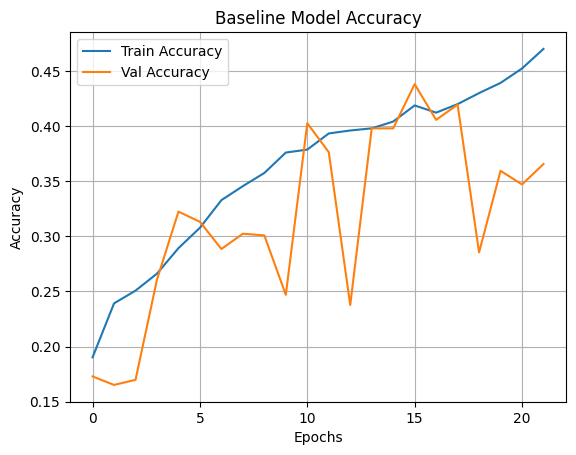

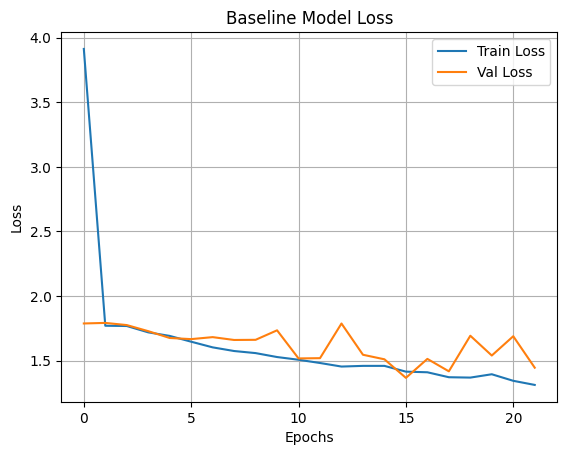

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Baseline Model Loss')
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

         Cat       0.39      0.48      0.43       120
     Chicken       0.63      0.74      0.68       1

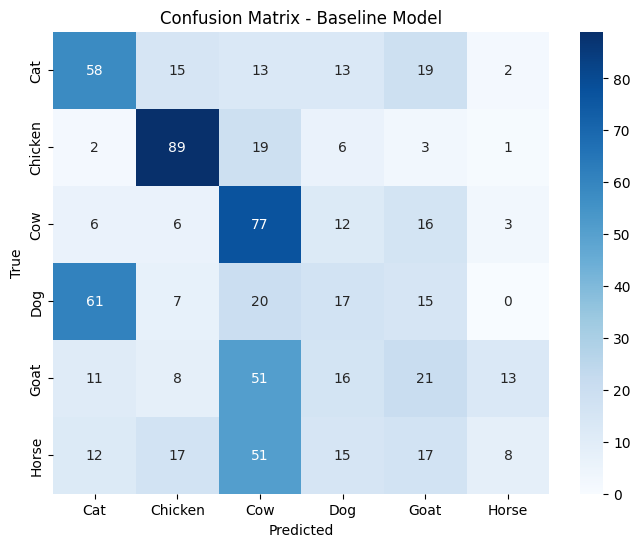

In [ ]:
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = deeper_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline Model')
plt.show()


In [ ]:
from tensorflow.keras.optimizers import SGD
deeper_model.compile(optimizer=SGD(), loss='categorical_crossentropy', metrics=['accuracy'])
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,710,438 (33.23 MB)

 Trainable params: 8,709,990 (33.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model_deeper_sgd.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
]

SGD_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2029 - loss: 2.8087

81/81 ━━━━━━━━━━━━━━━━━━━━ 586s 7s/step - accuracy: 0.2030 - loss: 2.8003 - val_accuracy: 0.1759 - val_loss: 1.7889
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 622s 7s/step - accuracy: 0.2300 - loss: 1.7538 - val_accuracy: 0.1698 - val_loss: 1.7984
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2809 - loss: 1.6796

81/81 ━━━━━━━━━━━━━━━━━━━━ 581s 7s/step - accuracy: 0.2809 - loss: 1.6796 - val_accuracy: 0.2022 - val_loss: 1.7763
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 607s 7s/step - accuracy: 0.3035 - loss: 1.6507 - val_accuracy: 0.1914 - val_loss: 1.7905
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3053 - loss: 1.6249

81/81 ━━━━━━━━━━━━━━━━━━━━ 620s 7s/step - accuracy: 0.3054 - loss: 1.6249 - val_accuracy: 0.3102 - val_loss: 1.6661
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3357 - loss: 1.5663

81/81 ━━━━━━━━━━━━━━━━━━━━ 593s 7s/step - accuracy: 0.3358 - loss: 1.5665 - val_accuracy: 0.3025 - val_loss: 1.6137
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3434 - loss: 1.5103

81/81 ━━━━━━━━━━━━━━━━━━━━ 617s 7s/step - accuracy: 0.3433 - loss: 1.5107 - val_accuracy: 0.3364 - val_loss: 1.5718
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3533 - loss: 1.5200

81/81 ━━━━━━━━━━━━━━━━━━━━ 616s 7s/step - accuracy: 0.3534 - loss: 1.5199 - val_accuracy: 0.3611 - val_loss: 1.5477
Epoch 9/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4004 - loss: 1.4829

81/81 ━━━━━━━━━━━━━━━━━━━━ 585s 7s/step - accuracy: 0.4002 - loss: 1.4831 - val_accuracy: 0.3966 - val_loss: 1.5248
Epoch 10/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 600s 7s/step - accuracy: 0.3814 - loss: 1.4557 - val_accuracy: 0.3426 - val_loss: 1.6172


Time taken 2 hr 45 mins

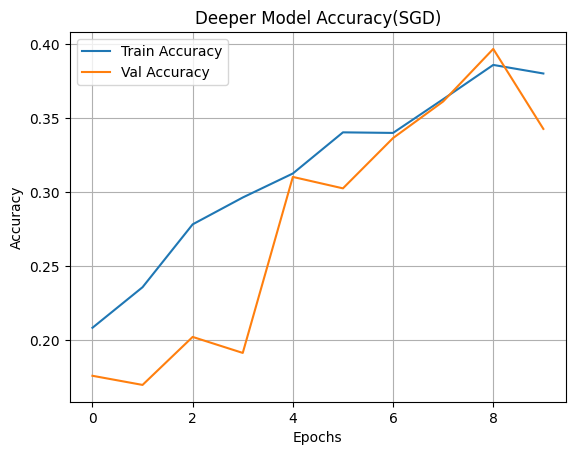

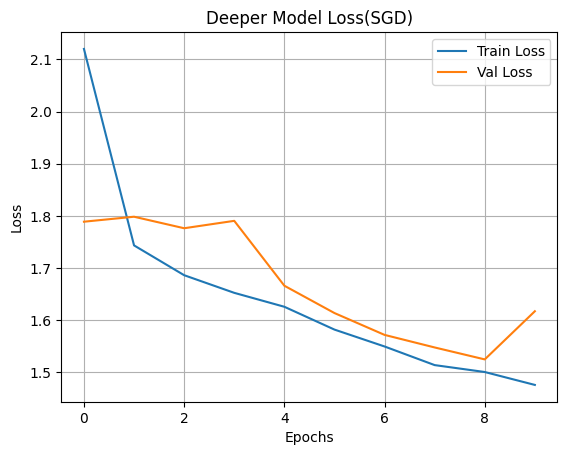

In [ ]:
plt.plot(SGD_history.history['accuracy'], label='Train Accuracy')
plt.plot(SGD_history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Deeper Model Accuracy(SGD)')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(SGD_history.history['loss'], label='Train Loss')
plt.plot(SGD_history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Deeper Model Loss(SGD)')
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

         Cat       0.41      0.47      0.44       120
     Chicken       0.

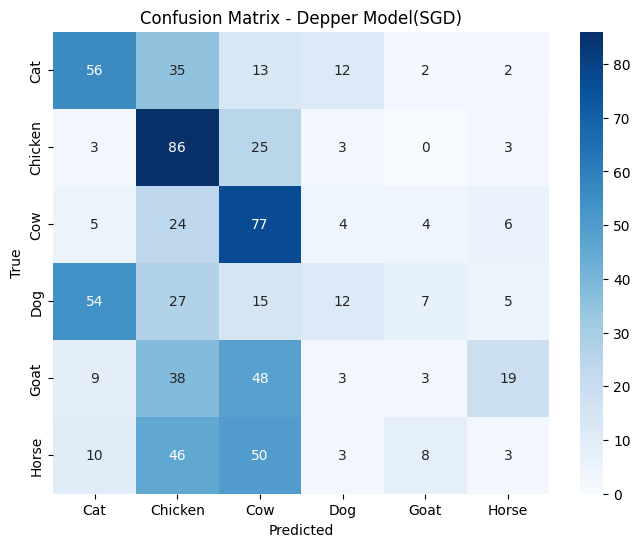

In [ ]:
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = deeper_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Depper Model(SGD)')
plt.show()


In [23]:
from tensorflow.keras.applications import ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
base_model.trainable = False
base_model.summary()
model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(1024, activation='relu'))
model.add(layers.Dense(6, activation='softmax'))

model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,692,038 (98.01 MB)

 Trainable params: 2,104,326 (8.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(64, 64), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(test_dir, target_size=(64, 64), batch_size=32, class_mode='categorical')

history = model.fit(train_generator, epochs=5, validation_data=val_generator)



Found 3240 images belonging to 6 classes.
Found 720 images belonging to 6 classes.
Epoch 1/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 885s 9s/step - accuracy: 0.1937 - loss: 1.8599 - val_accuracy: 0.2083 - val_loss: 1.7717
Epoch 2/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 859s 8s/step - accuracy: 0.2248 - loss: 1.7641 - val_accuracy: 0.2431 - val_loss: 1.7236
Epoch 3/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 845s 8s/step - accuracy: 0.2629 - loss: 1.7330 - val_accuracy: 0.2569 - val_loss: 1.7293
Epoch 4/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 891s 9s/step - accuracy: 0.2593 - loss: 1.7423 - val_accuracy: 0.2958 - val_loss: 1.7356
Epoch 5/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 963s 9s/step - accuracy: 0.2860 - loss: 1.7190 - val_accuracy: 0.2903 - val_loss: 1.6969


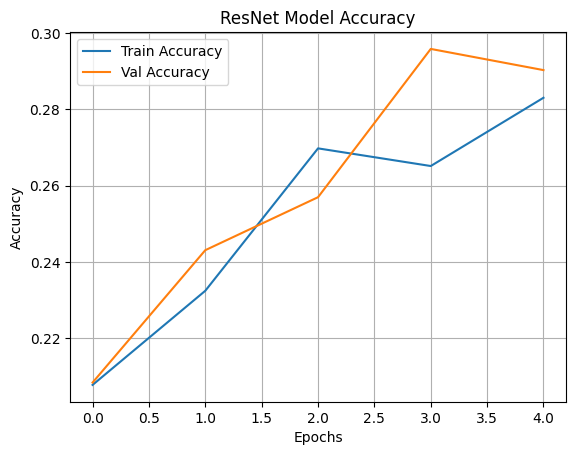

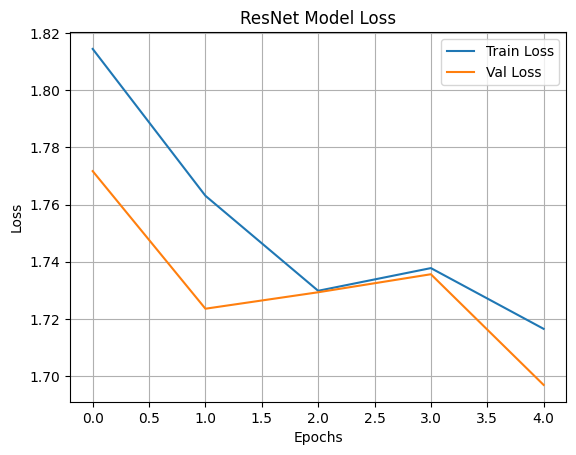

In [27]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet Model Loss')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
test_loss, test_acc = model.evaluate(val_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = predictions.argmax(axis=-1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 138s 6s/step - accuracy: 0.3084 - loss: 1.6741
Test Accuracy: 29.03%
23/23 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step


Classification Report:
              precision    recall  f1-score   support

         Cat       0.19      0.15      0.17       120
     Chicken       0.16      0.25      0.20       120
         Cow       0.16      0.15      0.16       120
         Dog       0.27      0.12      0.17       120
        Goat       0.17      0.13      0.15       120
       Horse       0.15      0.22      0.18       120

    accuracy                           0.17       720
   macro avg       0.18      0.17      0.17       720
weighted avg       0.18      0.17      0.17       720



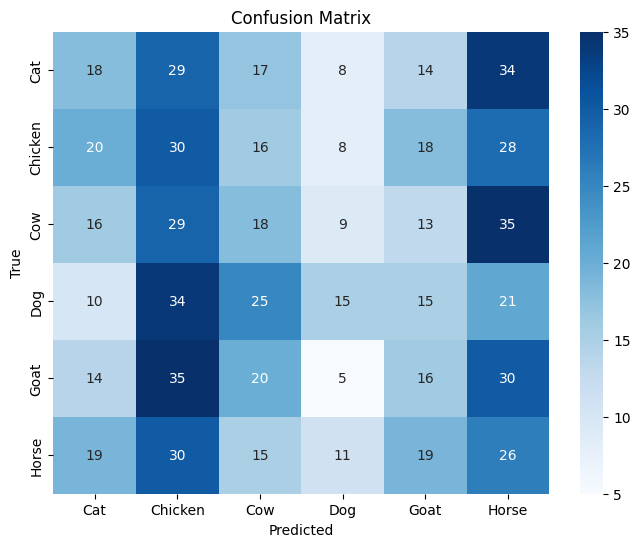

In [26]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()